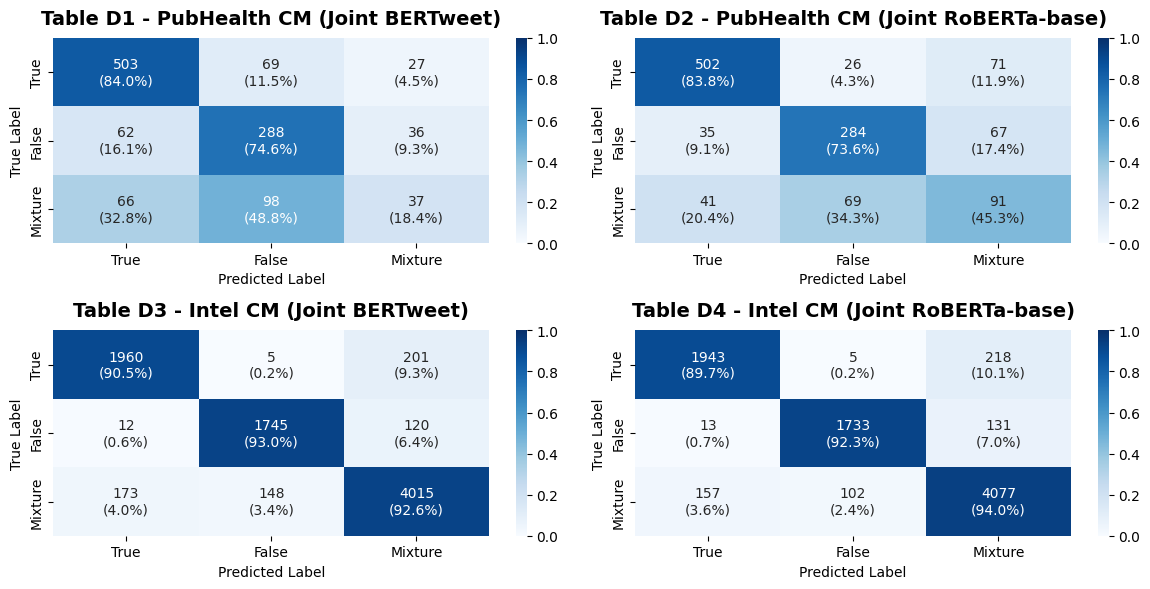

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define labels
labels = ['True', 'False', 'Mixture']

# Data for the four Confusion Matrices
data = {
    "Table D1 - PubHealth CM (Joint BERTweet)": np.array([
        [503, 69, 27],
        [62, 288, 36],
        [66, 98, 37]
    ]),
    "Table D2 - PubHealth CM (Joint RoBERTa-base)": np.array([
        [502, 26, 71],
        [35, 284, 67],
        [41, 69, 91]
    ]),
    "Table D3 - Intel CM (Joint BERTweet)": np.array([
        [1960, 5, 201],
        [12, 1745, 120],
        [173, 148, 4015]
    ]),
    "Table D4 - Intel CM (Joint RoBERTa-base)": np.array([
        [1943, 5, 218],
        [13, 1733, 131],
        [157, 102, 4077]
    ])
}



# Set up the figure for a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for i, (title, matrix) in enumerate(data.items()):
    # Calculate percentages for annotation
    row_sums = matrix.sum(axis=1)[:, np.newaxis]
    percentages = (matrix / row_sums * 100)

    # Inside your loop:
    # Normalize by row (True Label) so each row adds up to 1
    row_sums = matrix.sum(axis=1)[:, np.newaxis]
    normalized_matrix = matrix / row_sums

    
    # Create text labels: "Count (Percentage%)"
    annot_labels = np.array([
        [f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
        for row_v, row_p in zip(matrix, percentages)
    ])

    sns.heatmap(
        normalized_matrix, # Use normalized for the COLOR
        annot=annot_labels, # Use the string labels we created earlier for the TEXT
        fmt="", 
        cmap="Blues", 
        vmin=0, vmax=1, # Fix the scale from 0% to 100%
        xticklabels=labels, 
        yticklabels=labels, 
        ax=axes[i]
    )

    axes[i].set_title(title, fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

plt.tight_layout()
fig.savefig("confusion_matrices.png", dpi=300)
plt.show()